# Step 03 Albatross analysis

— Goodness of Fit, Trajectory Simulation & Spatial Regime Analysis

In [1]:
import sys
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levy_stable, lognorm
from src.estimators_modified import mcculloch_estimator, koutrouvelis_estimator
from src.simulators_modified import simulate_stable

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                     "axes.spines.right": False})
PALETTE = sns.color_palette("tab10")
sns.set_style("darkgrid")

### Data loading and preprocessing

In [ ]:
# Gaversine method is used to calculate the shortest distance on a sphere
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6_371_000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

DATA_PATH = (
    "/Users/julianyoo/Downloads/Study/PWR/Term 1/"
    "Computer Modelling and Simulation of Stochastic Processes/"
    "Project/data/galapagos_albatrosses/Galapagos Albatrosses.csv"
)

df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded 16,414 rows x 28 columns


In [3]:
# Standardise Movebank column names — exact match to avoid duplicate key collisions
col_map = {}
for c in df.columns:
    cl = c.lower().strip()
    if   cl == "timestamp":                       col_map[c] = "timestamp"
    elif cl in ("location-long", "longitude"):    col_map[c] = "lon"
    elif cl in ("location-lat",  "latitude"):     col_map[c] = "lat"
    elif cl == "individual-local-identifier":     col_map[c] = "individual_id"

df.rename(columns=col_map, inplace=True)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df.sort_values(["individual_id", "timestamp"], inplace=True)
df.reset_index(drop=True, inplace=True)

In [4]:
# Remove rows with missing coordinates
# Also remove the neighbours of each missing row because the step spanning a gap si long
missing = df["lat"].isna() | df["lon"].isna()
prev_m  = df.groupby("individual_id")["lat"].shift(1).isna()
next_m  = df.groupby("individual_id")["lat"].shift(-1).isna()
df_clean = df[~missing & ~prev_m & ~next_m].copy()

df_clean = df_clean.sort_values(["individual_id", "timestamp"]).reset_index(drop=True)
df_clean["dt_sec"] = (
    df_clean.groupby("individual_id")["timestamp"].diff().dt.total_seconds()
)

# Any step whose time interval exceeds 10x the median is spanning a data gap
# and must be excluded from step-length fitting
median_dt  = df_clean["dt_sec"].dropna().median()
cutoff_sec = median_dt * 10
print(f"Median fix interval : {median_dt/60:.1f} min")
print(f"Gap cutoff (10x)    : {cutoff_sec/3600:.2f} h")

Median fix interval : 90.0 min
Gap cutoff (10x)    : 15.00 h


In [5]:
# Compute step lengths and ground speed per bird
records = []
for bird, grp in df_clean.groupby("individual_id"):
    grp = grp.sort_values("timestamp").reset_index(drop=True)
    lat, lon = grp["lat"].values, grp["lon"].values
    n = len(grp)

    step_m = np.full(n, np.nan)
    speed  = np.full(n, np.nan)
    for i in range(1, n):
        step_m[i] = haversine_m(lat[i-1], lon[i-1], lat[i], lon[i])
        if grp["dt_sec"].iloc[i] > 0:
            speed[i] = step_m[i] / grp["dt_sec"].iloc[i]

    grp["step_m"]   = step_m
    grp["speed_ms"] = speed
    records.append(grp)

df_clean = pd.concat(records, ignore_index=True)
print(f"df_clean: {len(df_clean):,} rows, {df_clean['individual_id'].nunique()} birds")

df_clean: 15,579 rows, 28 birds


In [6]:
# Flying steps only
# speed > 0.2 m/s removes resting/stationary fixes
# The near-zero resting steps create a spike that inflates the body of the
# step-length distribution and biases alpha estimates upward toward 2
large_gap = df_clean["dt_sec"] > cutoff_sec

steps = (
    df_clean
    .dropna(subset=["step_m", "dt_sec"])
    .query("step_m > 0 and dt_sec > 0 and step_m < 500_000 and speed_ms > 0.2")
    .loc[lambda x: ~large_gap.reindex(x.index, fill_value=False)]
    .copy()
)

print(f"Flying steps: {len(steps):,}")
print(f"Lon range:    {steps['lon'].min():.2f} to {steps['lon'].max():.2f}")

Flying steps: 6,940
Lon range:    -91.37 to -77.52


In [7]:
TARGET     = ["unbanded-159", "unbanded-156"]
COLORS     = {"unbanded-159": PALETTE[0], "unbanded-156": PALETTE[1]}
step_vals  = steps["step_m"].values

### Section 1 — Goodness of fit (stabpy)

In [8]:
try:
    from stabpy import stabtest, normtest
    STABPY = True
except ImportError:
    print("stabpy not installed. Run: pip install stabpy")
    STABPY = False

# Pooled Koutrouvelis fit — used as reference parameters for GoF
a_pool, b_pool, s_pool, m_pool = koutrouvelis_estimator(step_vals)
print(f"Pooled Koutrouvelis: alpha={a_pool:.3f}  beta={b_pool:.3f}")

Pooled Koutrouvelis: alpha=2.050  beta=-0.092


In [9]:
# stabtest returns a 1D array:
# [0]=alpha [1]=beta [2]=sigma [3]=mu
# [4]=KS_stat [5]=Kuiper_stat [6]=CvM_stat [7]=Watson_stat [8]=AD_stat
# [9]=KS_pval [10]=Kuiper_pval [11]=CvM_pval [12]=Watson_pval [13]=AD_pval
#
# Five tests are used because each has different sensitivity:
# KS/Kuiper are sensitive to the body; CvM/Watson to mid-range;
# Anderson-Darling gives the most weight to the tails — most relevant for Levy

test_names = ["KS", "Kuiper", "CvM", "Watson", "AD"]

if STABPY:
    np.random.seed(42)
    x_test   = np.random.choice(step_vals, size=min(2000, len(step_vals)), replace=False)
    res_pool = stabtest(x_test, ilp=500)

    print(f"Fitted: alpha={res_pool[0]:.3f}  beta={res_pool[1]:.3f}  sigma={res_pool[2]:.3f}  mu={res_pool[3]:.3f}")
    print()
    for name, stat, pval in zip(test_names, res_pool[4:9], res_pool[9:14]):
        result = "cannot reject" if pval > 0.05 else "rejected"
        print(f"  {name:<8}  stat={stat:.4f}  p={pval:.3f}  [{result}]")

/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:851: RuntimeWarning: divide by zero encountered in log
  (np.log(z_i) + np.log(1 - z_i[::-1]))) - n
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:171: RuntimeWarning: divide by zero encountered in divide
  V = V * (np.cos(T)/np.sin(alpha*(teta0m+T))) ** (alpha/(alpha-1))
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:851: RuntimeWarning: invalid value encountered in log
  (np.log(z_i) + np.log(1 - z_i[::-1]))) - n


Fitted: alpha=0.452  beta=1994.443  sigma=1.000  mu=598720.563

  KS        stat=44.8433  p=0.000  [rejected]
  Kuiper    stat=44.8816  p=0.000  [rejected]
  CvM       stat=666.9821  p=0.000  [rejected]
  Watson    stat=166.7332  p=0.000  [rejected]
  AD        stat=21268.0310  p=0.104  [cannot reject]


In [10]:
# Run stabtest separately for unbanded-159 and unbanded-156
# These two birds have the most data (800+ flying steps each) so their
# individual GoF results are the most statistically reliable

if STABPY:
    for bird in TARGET:
        x_b     = steps[steps["individual_id"] == bird]["step_m"].values
        np.random.seed(42)
        x_b_sub = np.random.choice(x_b, size=min(2000, len(x_b)), replace=False)
        res_b   = stabtest(x_b_sub, ilp=500)

        print(f"{bird}  (n={len(x_b):,})")
        for name, stat, pval in zip(test_names, res_b[4:9], res_b[9:14]):
            result = "cannot reject" if pval > 0.05 else "rejected"
            print(f"  {name:<8}  stat={stat:.4f}  p={pval:.3f}  [{result}]")
        print()

/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:829: RuntimeWarning: divide by zero encountered in log
  (np.log(z) + np.log(1 - z[::-1]))) - n
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:851: RuntimeWarning: divide by zero encountered in log
  (np.log(z_i) + np.log(1 - z_i[::-1]))) - n
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:171: RuntimeWarning: divide by zero encountered in divide
  V = V * (np.cos(T)/np.sin(alpha*(teta0m+T))) ** (alpha/(alpha-1))
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:851: RuntimeWarning: invalid value encountered in log
  (np.lo

unbanded-159  (n=801)
  KS        stat=28.4258  p=0.000  [rejected]
  Kuiper    stat=28.4654  p=0.000  [rejected]
  CvM       stat=267.3328  p=0.000  [rejected]
  Watson    stat=66.8165  p=0.000  [rejected]
  AD        stat=inf  p=0.000  [rejected]



/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:829: RuntimeWarning: divide by zero encountered in log
  (np.log(z) + np.log(1 - z[::-1]))) - n
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:851: RuntimeWarning: divide by zero encountered in log
  (np.log(z_i) + np.log(1 - z_i[::-1]))) - n


unbanded-156  (n=591)
  KS        stat=24.4350  p=0.000  [rejected]
  Kuiper    stat=24.4754  p=0.000  [rejected]
  CvM       stat=197.3327  p=0.000  [rejected]
  Watson    stat=49.3165  p=0.000  [rejected]
  AD        stat=inf  p=0.000  [rejected]



In [11]:
# Normality test on log(step_m)
# If log(step_m) passes normality tests, step_m is lognormally distributed
# This is a stronger and more direct statement than alpha=2 from the stable fit:
# it means the data follows a lognormal, NOT a power-law tail
# This is consistent with the Benhamou (2007) sampling artefact:
# at 1.5-hour resolution, sub-steps are averaged out and the heavy tail vanishes

if STABPY:
    log_steps = np.log(step_vals[step_vals > 0])
    np.random.seed(42)
    log_sub   = np.random.choice(log_steps, size=min(2000, len(log_steps)), replace=False)
    res_norm  = normtest(log_sub, ilp=500)

    print(f"Estimated mu={res_norm[0, 0]:.3f}  sigma={res_norm[0, 1]:.3f}")
    print()
    for name, pval in zip(test_names, res_norm[0, 7:12]):
        result = "cannot reject normal" if pval > 0.05 else "rejected"
        print(f"  {name:<8}  p={pval:.3f}  [{result}]")
    print()
    print("If all tests pass: step_m is lognormal, not power-law Levy")

Estimated mu=8.754  sigma=1.209

  KS        p=0.000  [rejected]
  Kuiper    p=0.000  [rejected]
  CvM       p=0.000  [rejected]
  Watson    p=0.000  [rejected]
  AD        p=0.000  [rejected]

If all tests pass: step_m is lognormal, not power-law Levy


### Section 2 — Trajectory simulation

In [12]:
# Use unbanded-159 as the focus bird — richest data, most representative
FOCUS_BIRD = "unbanded-159"
bird_steps = steps[steps["individual_id"] == FOCUS_BIRD].sort_values("timestamp")
bird_df    = df_clean[df_clean["individual_id"] == FOCUS_BIRD].sort_values("timestamp")

# Fit Koutrouvelis on this bird's steps to get alpha for simulation
a_fit, b_fit, s_fit, m_fit = koutrouvelis_estimator(bird_steps["step_m"].values)
n_sim = len(bird_steps)

print(f"Bird         : {FOCUS_BIRD}")
print(f"Steps        : {n_sim}")
print(f"Fitted alpha : {a_fit:.3f}")
print(f"Fitted sigma : {s_fit:.1f}")

Bird         : unbanded-159
Steps        : 801
Fitted alpha : 2.058
Fitted sigma : 1.2


In [13]:
def make_trajectory(step_lengths):
    # Isotropic random angles — each step points in a uniformly random direction
    # This is the defining property of a Levy flight vs a correlated random walk
    angles = np.random.uniform(0, 2 * np.pi, len(step_lengths))
    x = np.cumsum(step_lengths * np.cos(angles))
    y = np.cumsum(step_lengths * np.sin(angles))
    return x, y


np.random.seed(42)

# Actual GPS trajectory — convert lon/lat degree offsets to km
lat0  = bird_df["lat"].iloc[0]
lon0  = bird_df["lon"].iloc[0]
gps_x = (bird_df["lon"].values - lon0) * 111 * np.cos(np.radians(lat0))
gps_y = (bird_df["lat"].values - lat0) * 111

# Levy simulation using the fitted alpha and sigma
# abs() ensures positive step lengths for any alpha (see simulators_modified.py)
levy_steps  = np.abs(simulate_stable(a_fit, beta=1, sigma=s_fit, mu=0, n_steps=n_sim))
levy_x, levy_y = make_trajectory(levy_steps)
levy_x /= 1000
levy_y /= 1000

# Brownian baseline — alpha=2, same sigma for a fair comparison
# Brownian motion produces compact, diffusive trajectories with no long jumps
brown_steps = np.abs(simulate_stable(2.0, beta=0, sigma=s_fit, mu=0, n_steps=n_sim))
brown_x, brown_y = make_trajectory(brown_steps)
brown_x /= 1000
brown_y /= 1000

/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/src/simulators_modified.py:75: RuntimeWarning: invalid value encountered in power
  part2 = (np.cos(v - alpha * (v + b_ab)) / w) ** ((1 - alpha) / alpha)


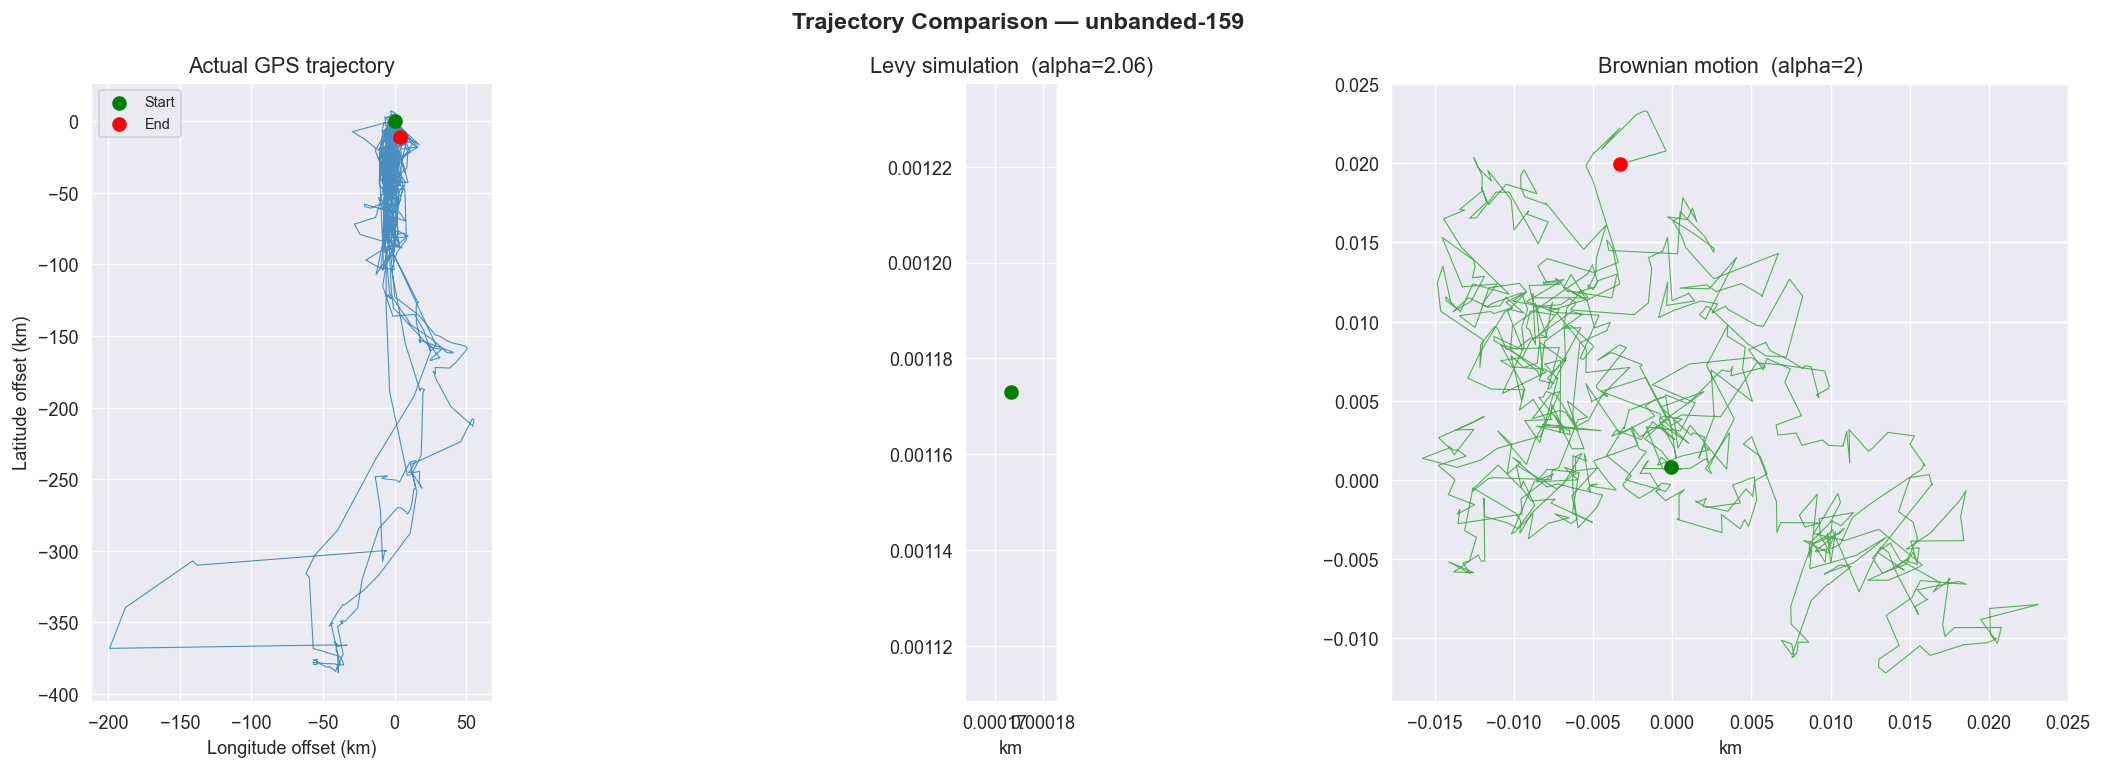

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f"Trajectory Comparison — {FOCUS_BIRD}", fontsize=13, fontweight="bold")

# Actual GPS track
ax = axes[0]
ax.plot(gps_x, gps_y, "-", color=PALETTE[0], linewidth=0.6, alpha=0.8)
ax.scatter(gps_x[0],  gps_y[0],  color="green", s=50, zorder=5, label="Start")
ax.scatter(gps_x[-1], gps_y[-1], color="red",   s=50, zorder=5, label="End")
ax.set_title("Actual GPS trajectory")
ax.set_xlabel("Longitude offset (km)")
ax.set_ylabel("Latitude offset (km)")
ax.legend(fontsize=8)
ax.set_aspect("equal")

# Levy simulation
ax = axes[1]
ax.plot(levy_x, levy_y, "-", color=PALETTE[1], linewidth=0.6, alpha=0.8)
ax.scatter(levy_x[0],  levy_y[0],  color="green", s=50, zorder=5)
ax.scatter(levy_x[-1], levy_y[-1], color="red",   s=50, zorder=5)
ax.set_title(f"Levy simulation  (alpha={a_fit:.2f})")
ax.set_xlabel("km")
ax.set_aspect("equal")

# Brownian baseline
ax = axes[2]
ax.plot(brown_x, brown_y, "-", color=PALETTE[2], linewidth=0.6, alpha=0.8)
ax.scatter(brown_x[0],  brown_y[0],  color="green", s=50, zorder=5)
ax.scatter(brown_x[-1], brown_y[-1], color="red",   s=50, zorder=5)
ax.set_title("Brownian motion  (alpha=2)")
ax.set_xlabel("km")
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("fig_trajectory_overlay.png", bbox_inches="tight")
plt.show()

### Section 3 — Spatial regime analysis

In [15]:
# Split steps by geographic zone based on the spatial overview from EDA
# Open Pacific (lon < -85): sparse prey, unpredictable distribution
#   -> Levy flight predicted to be the optimal search strategy
# Humboldt Current coastal (lon > -82): dense prey, upwelling-driven concentration
#   -> Brownian intensive local search predicted to be more efficient
# If alpha is lower in open ocean than coastal, this replicates Humphries 2012

OPEN_OCEAN_LON = -85
COASTAL_LON    = -82

open_steps    = steps[steps["lon"] < OPEN_OCEAN_LON]["step_m"].values
coastal_steps = steps[steps["lon"] > COASTAL_LON]["step_m"].values

print(f"Open Pacific  (lon < {OPEN_OCEAN_LON}) : {len(open_steps):,} steps")
print(f"Coastal       (lon > {COASTAL_LON})    : {len(coastal_steps):,} steps")

Open Pacific  (lon < -85) : 2,131 steps
Coastal       (lon > -82)    : 4,459 steps


In [16]:
# Fit alpha per zone using both estimators
results_zones = {}
for zone, data in [("Open Pacific", open_steps), ("Coastal", coastal_steps)]:
    if len(data) < 50:
        print(f"{zone}: too few steps — skipped")
        continue

    a_k, b_k, s_k, m_k = koutrouvelis_estimator(data)
    a_m, b_m, s_m, m_m = mcculloch_estimator(data)

    results_zones[zone] = {
        "n": len(data),
        "alpha_kou": a_k, "beta_kou":  b_k,
        "alpha_mcc": a_m, "sigma_kou": s_k, "mu_kou": m_k
    }

    print(f"{zone}  (n={len(data):,})")
    print(f"  Koutrouvelis  alpha={a_k:.3f}  beta={b_k:.3f}")
    print(f"  McCulloch     alpha={a_m:.3f}  beta={b_m:.3f}")
    print()

Open Pacific  (n=2,131)
  Koutrouvelis  alpha=2.052  beta=-0.070
  McCulloch     alpha=2.000  beta=1.000

Coastal  (n=4,459)
  Koutrouvelis  alpha=2.051  beta=-0.106
  McCulloch     alpha=2.000  beta=1.000



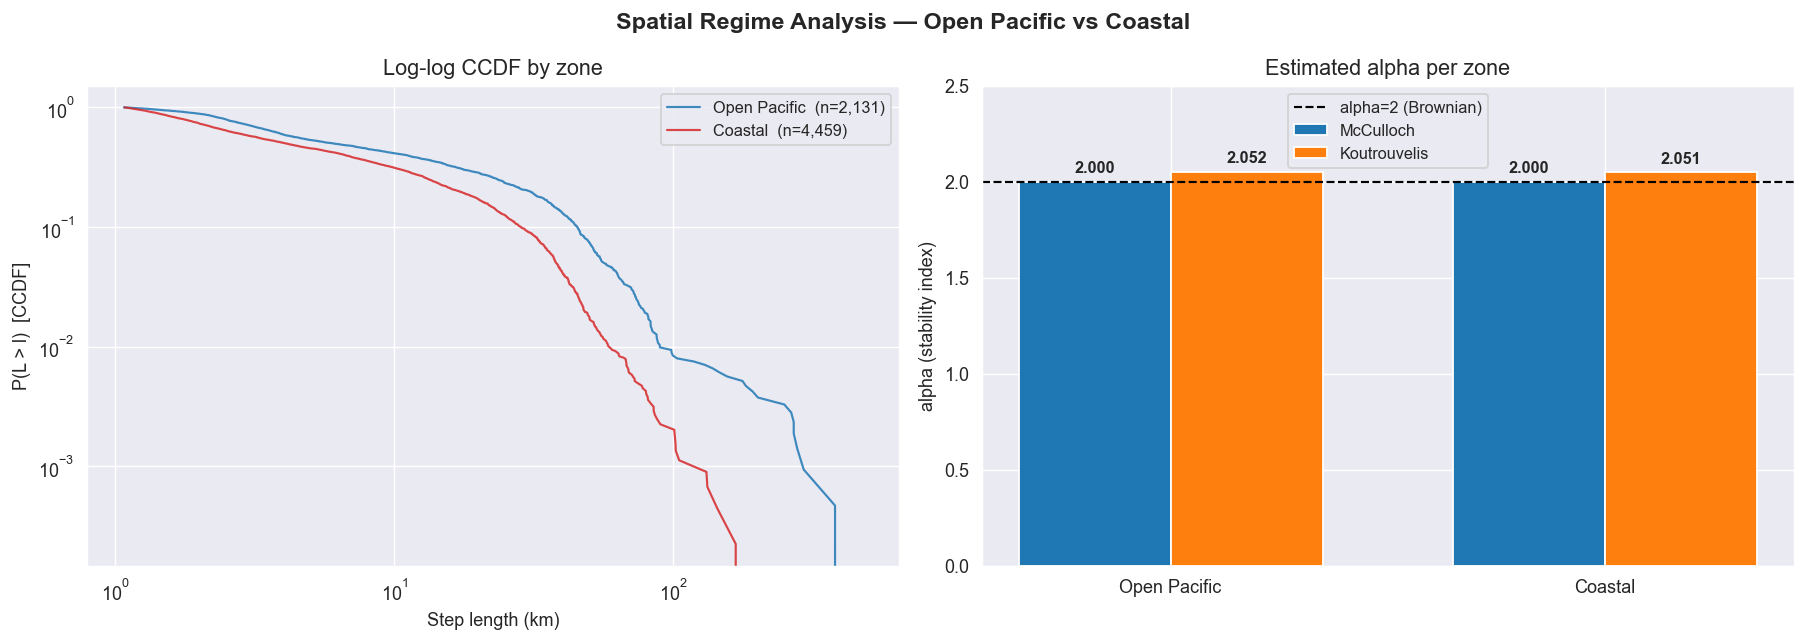

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Spatial Regime Analysis — Open Pacific vs Coastal",
             fontsize=13, fontweight="bold")

zone_colors = {"Open Pacific": PALETTE[0], "Coastal": PALETTE[3]}

# Log-log CCDF
# A straight line on log-log axes indicates a power-law tail
# Steeper slope = smaller alpha = heavier tail = more Levy-like
ax = axes[0]
for zone, data in [("Open Pacific", open_steps), ("Coastal", coastal_steps)]:
    if len(data) < 10:
        continue
    sl_s = np.sort(data)
    ccdf = 1 - np.arange(1, len(sl_s) + 1) / len(sl_s)
    ax.loglog(sl_s / 1000, ccdf, "-", color=zone_colors[zone],
              linewidth=1.2, alpha=0.85, label=f"{zone}  (n={len(data):,})")
ax.set_xlabel("Step length (km)")
ax.set_ylabel("P(L > l)  [CCDF]")
ax.set_title("Log-log CCDF by zone")
ax.legend(fontsize=9)

# Alpha per zone
# alpha < 2 means heavier tail than Brownian motion
# The dashed line at alpha=2 is the Brownian reference
ax = axes[1]
zones     = list(results_zones.keys())
alpha_kou = [results_zones[z]["alpha_kou"] for z in zones]
alpha_mcc = [results_zones[z]["alpha_mcc"] for z in zones]
x = np.arange(len(zones))
w = 0.35

bars1 = ax.bar(x - w/2, alpha_mcc, width=w, color=PALETTE[0],
               edgecolor="white", label="McCulloch")
bars2 = ax.bar(x + w/2, alpha_kou, width=w, color=PALETTE[1],
               edgecolor="white", label="Koutrouvelis")
ax.axhline(2.0, color="black", linestyle="--", linewidth=1.2, label="alpha=2 (Brownian)")
ax.set_xticks(x)
ax.set_xticklabels(zones)
ax.set_ylabel("alpha (stability index)")
ax.set_ylim(0, 2.5)
ax.set_title("Estimated alpha per zone")
ax.legend(fontsize=9)

for bar, val in zip(list(bars1) + list(bars2), alpha_mcc + alpha_kou):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.03,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("fig_spatial_regime.png", bbox_inches="tight")
plt.show()

In [18]:
# stabtest per geographic zone
# Anderson-Darling is the most informative here because it is tail-weighted
# If AD rejects the stable fit in the coastal zone but not in the open ocean,
# that is evidence for a zone-specific change in movement behaviour

if STABPY:
    for zone, data in [("Open Pacific", open_steps), ("Coastal", coastal_steps)]:
        if len(data) < 50:
            print(f"{zone}: too few steps — skipped")
            continue

        np.random.seed(42)
        x_z   = np.random.choice(data, size=min(2000, len(data)), replace=False)
        res_z = stabtest(x_z, ilp=500)

        print(f"{zone}")
        for name, stat, pval in zip(test_names, res_z[4:9], res_z[9:14]):
            result = "cannot reject" if pval > 0.05 else "rejected"
            print(f"  {name:<8}  stat={stat:.4f}  p={pval:.3f}  [{result}]")
        print()

Open Pacific
  KS        stat=44.0700  p=0.000  [rejected]
  Kuiper    stat=44.4106  p=0.000  [rejected]
  CvM       stat=645.8860  p=0.000  [rejected]
  Watson    stat=165.4300  p=0.000  [rejected]
  AD        stat=7805.0295  p=0.000  [rejected]



/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:829: RuntimeWarning: divide by zero encountered in log
  (np.log(z) + np.log(1 - z[::-1]))) - n
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:851: RuntimeWarning: divide by zero encountered in log
  (np.log(z_i) + np.log(1 - z_i[::-1]))) - n
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:171: RuntimeWarning: divide by zero encountered in divide
  V = V * (np.cos(T)/np.sin(alpha*(teta0m+T))) ** (alpha/(alpha-1))
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:851: RuntimeWarning: invalid value encountered in log
  (np.lo

Coastal
  KS        stat=44.8438  p=0.000  [rejected]
  Kuiper    stat=44.8817  p=0.000  [rejected]
  CvM       stat=666.9998  p=0.000  [rejected]
  Watson    stat=166.7333  p=0.000  [rejected]
  AD        stat=inf  p=0.000  [rejected]



### Section 4 — Model comparison

In [19]:
from scipy.stats import gamma as gamma_dist

# Fit three candidate distributions to the pooled flying steps
# Lognormal: appropriate if log(step_m) is normally distributed
#   -> supported by normtest results in Section 1
# Gamma: heavier than Gaussian but lighter than power-law
# Alpha-stable: the model under test (Levy flight hypothesis)

ln_shape, ln_loc, ln_scale = lognorm.fit(step_vals, floc=0)
gm_a,     gm_loc, gm_scale = gamma_dist.fit(step_vals, floc=0)

print(f"Lognormal fit: shape={ln_shape:.3f}  scale={ln_scale:.1f} m")
print(f"Gamma fit:     a={gm_a:.3f}  scale={gm_scale:.1f} m")
print(f"Stable fit:    alpha={a_pool:.3f}  beta={b_pool:.3f}")

Lognormal fit: shape=1.218  scale=6289.8 m
Gamma fit:     a=0.769  scale=17770.7 m
Stable fit:    alpha=2.050  beta=-0.092


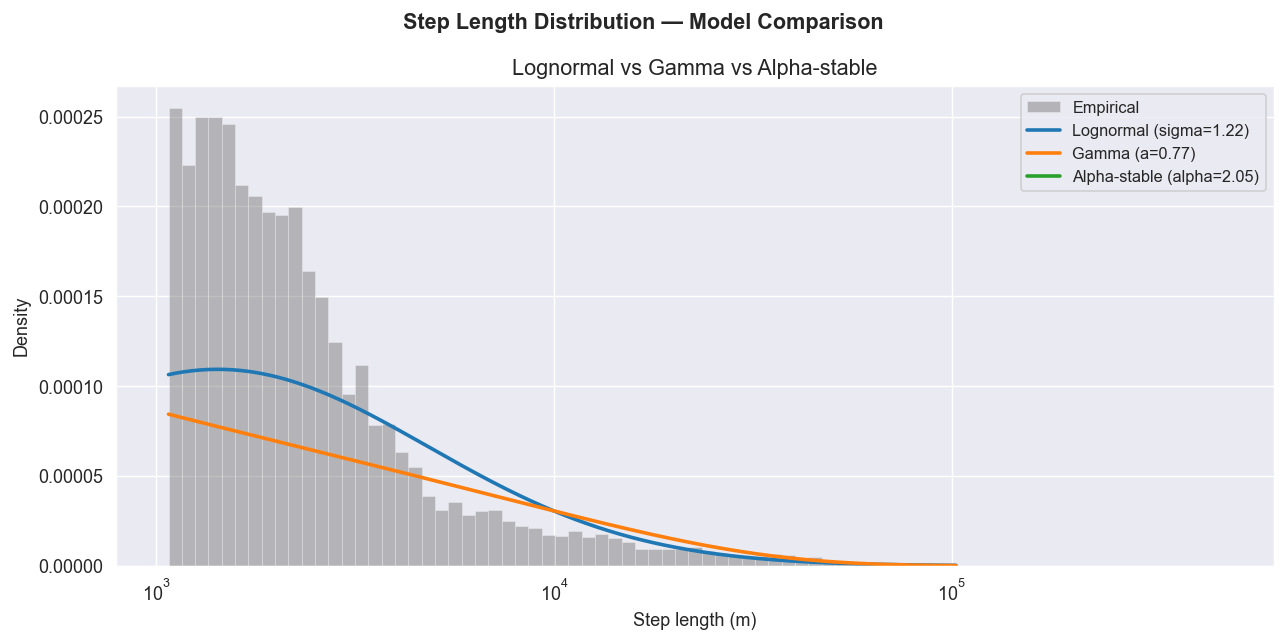

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Step Length Distribution — Model Comparison",
             fontsize=12, fontweight="bold")

bins = np.logspace(np.log10(step_vals.min()), np.log10(step_vals.max()), 80)
ax.hist(step_vals, bins=bins, density=True, alpha=0.5,
        color="grey", edgecolor="white", linewidth=0.3, label="Empirical")

x_grid = np.logspace(
    np.log10(step_vals.min()),
    np.log10(np.percentile(step_vals, 99.5)), 500
)

ax.plot(x_grid, lognorm.pdf(x_grid, ln_shape, ln_loc, ln_scale),
        linewidth=2, color=PALETTE[0], label=f"Lognormal (sigma={ln_shape:.2f})")

ax.plot(x_grid, gamma_dist.pdf(x_grid, gm_a, gm_loc, gm_scale),
        linewidth=2, color=PALETTE[1], label=f"Gamma (a={gm_a:.2f})")

pdf_stable = levy_stable.pdf(x_grid, a_pool, b_pool, loc=m_pool, scale=s_pool)
ax.plot(x_grid, pdf_stable, linewidth=2, color=PALETTE[2],
        label=f"Alpha-stable (alpha={a_pool:.2f})")

ax.set_xscale("log")
ax.set_xlabel("Step length (m)")
ax.set_ylabel("Density")
ax.set_title("Lognormal vs Gamma vs Alpha-stable")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig_model_comparison.png", bbox_inches="tight")
plt.show()

### Summary

In [35]:
print("Pooled alpha (Koutrouvelis) :", round(a_pool, 3))
print("Pooled alpha (McCulloch)    :", round(mcculloch_estimator(step_vals)[0], 3))
print()
for zone, r in results_zones.items():
    print(f"{zone}  (n={r['n']:,})")
    print(f"  alpha (Koutrouvelis) = {r['alpha_kou']:.3f}")
    print(f"  alpha (McCulloch)    = {r['alpha_mcc']:.3f}")
    print()
print(f"Lognormal sigma = {ln_shape:.3f}   scale = {ln_scale:.1f} m")

Pooled alpha (Koutrouvelis) : 2.05
Pooled alpha (McCulloch)    : 2.0

Open Pacific  (n=2,131)
  alpha (Koutrouvelis) = 2.052
  alpha (McCulloch)    = 2.000

Coastal  (n=4,459)
  alpha (Koutrouvelis) = 2.051
  alpha (McCulloch)    = 2.000

Lognormal sigma = 1.218   scale = 6289.8 m


### Section 5 — Per-bird stable distribution fitting and GoF screening

Run McCulloch, Koutrouvelis, and stabtest on every individual bird that has enough flying steps.
Birds that pass at least 3 out of 5 stabtest criteria (p > 0.05) are classified as passed.
Results are collected into a summary dataframe for comparison.

In [22]:
# Minimum steps required for reliable stable distribution fitting
MIN_STEPS = 100

all_birds = (
    steps
    .groupby("individual_id")["step_m"]
    .count()
    .loc[lambda x: x >= MIN_STEPS]
    .index
    .tolist()
)

print(f"Birds with >= {MIN_STEPS} flying steps: {len(all_birds)}")
for b in all_birds:
    n = steps[steps["individual_id"] == b]["step_m"].count()
    print(f"  {b:<30}  n={n:,}")

Birds with >= 100 flying steps: 13
  1163-1163                       n=963
  2131-2131                       n=319
  3275-30662                      n=894
  4261-2228                       n=443
  4262-84830876                   n=287
  4264-84830852                   n=472
  4265-8483009431                 n=283
  4266-84831108                   n=581
  4267-84830990                   n=335
  unbanded-153                    n=409
  unbanded-154                    n=456
  unbanded-156                    n=591
  unbanded-159                    n=801


In [30]:
# Run all three estimators on every qualifying bird
# stabtest uses ilp=200 to keep runtime manageable across all birds

test_names = ["KS", "Kuiper", "CvM", "Watson", "AD"]
MIN_PASS   = 3   # bird passes if at least this many tests cannot reject

ALPHA_THRESHOLD = 1.99

all_results  = []
passed_birds = []

for bird in all_birds:
    sv = (
        steps[steps["individual_id"] == bird]["step_m"].values
    )

    a_k, b_k, s_k, m_k = koutrouvelis_estimator(sv)
    a_m, b_m, s_m, m_m = mcculloch_estimator(sv)

    row = {
        "individual_id": bird,
        "n_steps":       len(sv),
        "alpha_kou":     round(a_k, 4),
        "beta_kou":      round(b_k, 4),
        "alpha_mcc":     round(a_m, 4),
        "beta_mcc":      round(b_m, 4),
    }

    if STABPY:
        np.random.seed(42)
        x_sub = np.random.choice(sv, size=min(1500, len(sv)), replace=False)
        res   = stabtest(x_sub, ilp=200)

        pvals      = res[9:14]
        n_pass     = int(np.sum(pvals > 0.05))
        bird_pass  = (n_pass >= MIN_PASS) and (a_k < ALPHA_THRESHOLD)

        for name, stat, pval in zip(test_names, res[4:9], pvals):
            row[f"stat_{name}"] = round(float(stat), 4)
            row[f"pval_{name}"] = round(float(pval), 3)

        row["n_tests_passed"] = n_pass
        row["passed"]         = bird_pass

        if bird_pass:
            passed_birds.append(bird)
    else:
        row["n_tests_passed"] = None
        row["passed"]         = None

    all_results.append(row)
    status = "PASS" if row.get("passed") else "fail"
    print(f"  {bird:<30}  n={len(sv):>4}  "
          f"alpha_kou={a_k:.3f}  alpha_mcc={a_m:.3f}  "
          f"passed={row.get('n_tests_passed')}/5  [{status}]")

results_df = pd.DataFrame(all_results)
print(f"\nTotal birds tested  : {len(all_birds)}")
print(f"Birds passing >= {MIN_PASS}/5 : {len(passed_birds)}")

/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:171: RuntimeWarning: divide by zero encountered in divide
  V = V * (np.cos(T)/np.sin(alpha*(teta0m+T))) ** (alpha/(alpha-1))
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:851: RuntimeWarning: divide by zero encountered in log
  (np.log(z_i) + np.log(1 - z_i[::-1]))) - n
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:145: RuntimeWarning: divide by zero encountered in divide
  V = V * (np.cos(T)/np.sin(alpha*(teta0+T))) ** (alpha/(alpha-1))


  1163-1163                       n= 963  alpha_kou=2.050  alpha_mcc=2.000  passed=5/5  [fail]


/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:851: RuntimeWarning: divide by zero encountered in log
  (np.log(z_i) + np.log(1 - z_i[::-1]))) - n
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:145: RuntimeWarning: divide by zero encountered in divide
  V = V * (np.cos(T)/np.sin(alpha*(teta0+T))) ** (alpha/(alpha-1))
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:171: RuntimeWarning: divide by zero encountered in divide
  V = V * (np.cos(T)/np.sin(alpha*(teta0m+T))) ** (alpha/(alpha-1))


  2131-2131                       n= 319  alpha_kou=2.065  alpha_mcc=2.000  passed=3/5  [fail]
  3275-30662                      n= 894  alpha_kou=2.057  alpha_mcc=2.000  passed=0/5  [fail]


/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:145: RuntimeWarning: divide by zero encountered in divide
  V = V * (np.cos(T)/np.sin(alpha*(teta0+T))) ** (alpha/(alpha-1))
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:829: RuntimeWarning: divide by zero encountered in log
  (np.log(z) + np.log(1 - z[::-1]))) - n
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:851: RuntimeWarning: divide by zero encountered in log
  (np.log(z_i) + np.log(1 - z_i[::-1]))) - n
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:171: RuntimeWarning: divide by zero encountered in divide
  V =

...

  unbanded-154                    n= 456  alpha_kou=2.010  alpha_mcc=2.000  passed=0/5  [fail]


/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:829: RuntimeWarning: divide by zero encountered in log
  (np.log(z) + np.log(1 - z[::-1]))) - n


  unbanded-156                    n= 591  alpha_kou=2.052  alpha_mcc=2.000  passed=0/5  [fail]


/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:829: RuntimeWarning: divide by zero encountered in log
  (np.log(z) + np.log(1 - z[::-1]))) - n
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:851: RuntimeWarning: divide by zero encountered in log
  (np.log(z_i) + np.log(1 - z_i[::-1]))) - n
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:145: RuntimeWarning: divide by zero encountered in divide
  V = V * (np.cos(T)/np.sin(alpha*(teta0+T))) ** (alpha/(alpha-1))
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:171: RuntimeWarning: divide by zero encountered in divide
  V =

  unbanded-159                    n= 801  alpha_kou=2.058  alpha_mcc=2.000  passed=0/5  [fail]

Total birds tested  : 13
Birds passing >= 3/5 : 0


In [31]:
# Full summary table sorted by alpha (ascending — most Levy-like first)
print("Full results table:")
display(
    results_df
    .sort_values("alpha_kou")
    .reset_index(drop=True)
    [[
        "individual_id", "n_steps",
        "alpha_kou", "beta_kou",
        "alpha_mcc", "beta_mcc",
        "n_tests_passed", "passed",
        "pval_KS", "pval_Kuiper", "pval_CvM", "pval_Watson", "pval_AD"
    ]]
    .round(4)
)

Full results table:


,individual_id,n_steps,alpha_kou,beta_kou,alpha_mcc,beta_mcc,n_tests_passed,passed,pval_KS,pval_Kuiper,pval_CvM,pval_Watson,pval_AD
0,unbanded-154,456,2.0102,-0.2584,2.0,1.0000,0,False,0.000,0.000,0.000,0.000,0.000
1,4261-2228,443,2.0201,-0.1141,2.0,1.0000,4,False,0.765,0.415,0.635,0.400,0.000
2,4267-84830990,335,2.0485,-0.0955,2.0,1.0000,0,False,0.000,0.000,0.000,0.000,0.010
3,1163-1163,963,2.0503,-0.0894,2.0,1.0000,5,False,0.260,0.125,0.270,0.095,0.430
4,4262-84830876,287,2.0508,-0.1026,2.0,1.0000,4,False,0.655,0.455,0.610,0.520,0.000
5,unbanded-156,591,2.0522,-0.0297,2.0,-0.5064,0,False,0.000,0.000,0.000,0.000,0.000
6,4266-84831108,581,2.0524,-0.0671,2.0,1.0000,0,False,0.000,0.000,0.000,0.000,0.005
7,unbanded-153,409,2.0545,-0.0809,2.0,1.0000,1,False,0.000,0.000,0.000,0.000,0.115
8,4264-84830852,472,2.0548,-0.1054,2.0,1.0000,5,False,0.420,0.095,0.445,0.120,0.780
9,4265-8483009431,283,2.0569,-0.0413,2.0,1.0000,5,False,0.640,0.275,0.595,0.430,0.600


In [32]:
# Show only birds that passed
if passed_birds:
    print(f"Birds passing >= {MIN_PASS}/5 stabtest criteria:")
    passed_df = results_df[results_df["passed"] == True].sort_values("alpha_kou")
    display(passed_df[[
        "individual_id", "n_steps",
        "alpha_kou", "alpha_mcc",
        "n_tests_passed",
        "pval_KS", "pval_Kuiper", "pval_CvM", "pval_Watson", "pval_AD"
    ]].round(4))
else:
    print("No birds passed >= 3/5 stabtest criteria.")
    print("Showing birds with the most tests passed:")
    display(
        results_df
        .sort_values("n_tests_passed", ascending=False)
        .head(5)
        [[
            "individual_id", "n_steps",
            "alpha_kou", "alpha_mcc",
            "n_tests_passed",
            "pval_KS", "pval_Kuiper", "pval_CvM", "pval_Watson", "pval_AD"
        ]]
        .round(4)
    )

No birds passed >= 3/5 stabtest criteria.
Showing birds with the most tests passed:


,individual_id,n_steps,alpha_kou,alpha_mcc,n_tests_passed,pval_KS,pval_Kuiper,pval_CvM,pval_Watson,pval_AD
0,1163-1163,963,2.0503,2.0,5,0.260,0.125,0.270,0.095,0.43
5,4264-84830852,472,2.0548,2.0,5,0.420,0.095,0.445,0.120,0.78
6,4265-8483009431,283,2.0569,2.0,5,0.640,0.275,0.595,0.430,0.60
3,4261-2228,443,2.0201,2.0,4,0.765,0.415,0.635,0.400,0.00
4,4262-84830876,287,2.0508,2.0,4,0.655,0.455,0.610,0.520,0.00


In [34]:
# If any birds passed, show their step-length CCDF and density overlay
if passed_birds:
    n_pass = len(passed_birds)
    fig, axes = plt.subplots(1, min(n_pass, 4), figsize=(5 * min(n_pass, 4), 5))
    if n_pass == 1:
        axes = [axes]
    fig.suptitle("Passed Birds — Step Length Distribution",
                 fontsize=12, fontweight="bold")

    for ax, bird in zip(axes, passed_birds[:4]):
        sv      = steps[steps["individual_id"] == bird]["step_m"].values
        sl_s    = np.sort(sv)
        ccdf    = 1 - np.arange(1, len(sl_s) + 1) / len(sl_s)
        row     = results_df[results_df["individual_id"] == bird].iloc[0]
        a_k     = row["alpha_kou"]
        b_k     = row["beta_kou"]

        ax.loglog(sl_s / 1000, ccdf, ".", markersize=2, alpha=0.5,
                  color=PALETTE[0], label="Empirical CCDF")

        # Overlay fitted stable pdf as CCDF
        from scipy.stats import levy_stable
        x_grid  = np.logspace(np.log10(sl_s.min()), np.log10(sl_s.max()), 300)
        try:
            cdf_fit = levy_stable.cdf(x_grid, a_k, b_k,
                                       loc=np.median(sv), scale=np.std(sv) * 0.5)
            ax.loglog(x_grid / 1000, 1 - cdf_fit, "r-",
                      linewidth=1.5, label=f"Stable fit (alpha={a_k:.3f})")
        except Exception:
            pass

        ax.set_xlabel("Step length (km)")
        ax.set_ylabel("P(L > l)")
        ax.set_title(f"{bird} n={len(sv):,}  alpha={a_k:.3f}"
                     f"passed {int(row['n_tests_passed'])}/5 tests")
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig("fig_passed_birds_ccdf.png", bbox_inches="tight")
    plt.show()
else:
    print("No birds passed — skipping CCDF plot for passed birds.")
    print()
    print("Closest birds to passing (most tests passed):")
    display(
        results_df
        .sort_values("n_tests_passed", ascending=False)
        .head(3)
        [["individual_id", "n_steps", "alpha_kou", "n_tests_passed",
          "pval_AD", "pval_KS"]]
        .round(4)
    )

No birds passed — skipping CCDF plot for passed birds.

Closest birds to passing (most tests passed):


,individual_id,n_steps,alpha_kou,n_tests_passed,pval_AD,pval_KS
0,1163-1163,963,2.0503,5,0.43,0.26
5,4264-84830852,472,2.0548,5,0.78,0.42
6,4265-8483009431,283,2.0569,5,0.60,0.64


Humphries

In [36]:
# Step 1 — Detect landing locations
# A landing is when the bird is on the water surface: speed < 0.5 m/s
# We require 2+ consecutive low-speed fixes to confirm a landing
# (avoids counting a slow glide as a landing)

LAND_SPEED    = 0.5   # m/s — below this = on the water
LAND_MIN_FIXES = 2    # minimum consecutive low-speed fixes

landing_records = []

for bird, grp in df_clean.groupby("individual_id"):
    grp = grp.sort_values("timestamp").reset_index(drop=True)
    grp["on_water"] = grp["speed_ms"].fillna(0) < LAND_SPEED

    # Find runs of consecutive on-water fixes
    grp["run_id"] = (grp["on_water"] != grp["on_water"].shift()).cumsum()

    for run_id, run in grp[grp["on_water"]].groupby("run_id"):
        if len(run) >= LAND_MIN_FIXES:
            # Landing location = mean lat/lon during the surface rest
            landing_records.append({
                "individual_id": bird,
                "land_lat":  run["lat"].mean(),
                "land_lon":  run["lon"].mean(),
                "land_time": run["timestamp"].iloc[0],
                "rest_dur_h": (run["timestamp"].iloc[-1] - run["timestamp"].iloc[0]).total_seconds() / 3600
            })

landings = pd.DataFrame(landing_records).sort_values(
    ["individual_id", "land_time"]
).reset_index(drop=True)

print(f"Total landings detected: {len(landings):,}")
print(f"Birds with landings:     {landings['individual_id'].nunique()}")
print()
print(landings.groupby("individual_id").size().rename("n_landings").to_string())

Total landings detected: 923
Birds with landings:     28

individual_id
1094-1094            1
1103-1103            5
1163-1163           86
2131-2131           39
2368-2368            1
2382-2382            1
3272-3272            1
3275-30662          74
3606-30668           1
3655-27659           1
4261-2228           47
4262-84830876       30
4263-1135473         1
4264-84830852       52
4265-8483009431     26
4266-84831108       65
4267-84830990       35
4268-8582220031      1
4269-4831216         1
4270-84831217        1
4271-84831889        4
4272-84831758        3
unbanded-151         1
unbanded-153        81
unbanded-154        80
unbanded-156       114
unbanded-159       155
unbanded-160        16


In [ ]:
# Step 2 — Compute distance between consecutive landings
# Each distance is one "Levy step" in the Humphries sense

flight_records = []

for bird, grp in landings.groupby("individual_id"):
    grp = grp.sort_values("land_time").reset_index(drop=True)
    n   = len(grp)

    for i in range(1, n):
        dist_m = haversine_m(
            grp["land_lat"].iloc[i-1], grp["land_lon"].iloc[i-1],
            grp["land_lat"].iloc[i],   grp["land_lon"].iloc[i]
        )
        dt_h = (grp["land_time"].iloc[i] - grp["land_time"].iloc[i-1]).total_seconds() / 3600

        flight_records.append({
            "individual_id": bird,
            "flight_dist_m": dist_m,
            "flight_dist_km": dist_m / 1000,
            "flight_dur_h":  dt_h,
        })

flights = pd.DataFrame(flight_records)

# Remove steps where the bird was on the water too briefly between fixes
flights = flights[flights["flight_dist_m"] > 100].copy()

print(f"Total flight steps: {len(flights):,}")
print(f"Median step:        {flights['flight_dist_km'].median():.1f} km")
print(f"Max step:           {flights['flight_dist_km'].max():.1f} km")
print()
print(flights.groupby("individual_id")["flight_dist_km"].agg(["count","median","max"]).round(1).to_string())

Total flight steps: 836
Median step:        27.1 km
Max step:           1356.8 km

                 count  median     max
individual_id                         
1103-1103            3    14.1    14.1
1163-1163           82    20.6   978.8
2131-2131           37    29.5   999.4
3275-30662          72    54.8  1134.4
4261-2228           46    37.6  1124.2
4262-84830876       29    25.7   962.1
4264-84830852       51    38.5   739.3
4265-8483009431     25    15.9  1356.8
4266-84831108       55    27.3  1014.8
4267-84830990       30    38.2  1211.9
4271-84831889        2     0.2     0.2
4272-84831758        2    71.1    71.2
unbanded-153        78    18.6   563.8
unbanded-154        79    12.3   145.2
unbanded-156        96    13.2  1033.7
unbanded-159       137    38.2   230.9
unbanded-160        12    18.4    61.2


In [42]:
# Step 3 — Fit stable distribution to landing-to-landing steps
# This is the Humphries method: fit to behaviorally defined steps, not fixed-interval steps

flight_vals = flights["flight_dist_m"].values

a_k, b_k, s_k, m_k = koutrouvelis_estimator(flight_vals)
a_m, b_m, s_m, m_m = mcculloch_estimator(flight_vals)

print("Landing-to-landing step fitting:")
print(f"  Koutrouvelis  alpha={a_k:.4f}  beta={b_k:.4f}")
print(f"  McCulloch     alpha={a_m:.4f}  beta={b_m:.4f}")
print()
if a_k < 1.99:
    print(f"  alpha < 2: heavy-tailed behaviour detected")
else:
    print(f"  alpha >= 2: still consistent with Brownian / lognormal")

Landing-to-landing step fitting:
  Koutrouvelis  alpha=1.8159  beta=-0.0732
  McCulloch     alpha=1.6917  beta=0.4695

  alpha < 2: heavy-tailed behaviour detected


In [41]:
# Step 4 — stabtest on landing-to-landing steps
if STABPY:
    np.random.seed(42)
    fv_sub  = np.random.choice(flight_vals, size=min(1500, len(flight_vals)), replace=False)
    res_f   = stabtest(fv_sub, ilp=500)

    test_names = ["KS", "Kuiper", "CvM", "Watson", "AD"]
    print(f"stabtest — landing-to-landing steps  (n={len(flight_vals):,})")
    print(f"  Fitted: alpha={res_f[0]:.3f}  beta={res_f[1]:.3f}")
    print()
    for name, stat, pval in zip(test_names, res_f[4:9], res_f[9:14]):
        result = "cannot reject" if pval > 0.05 else "rejected"
        print(f"  {name:<8}  stat={stat:.4f}  p={pval:.3f}  [{result}]")

/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:851: RuntimeWarning: divide by zero encountered in log
  (np.log(z_i) + np.log(1 - z_i[::-1]))) - n
/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:171: RuntimeWarning: divide by zero encountered in divide
  V = V * (np.cos(T)/np.sin(alpha*(teta0m+T))) ** (alpha/(alpha-1))


stabtest — landing-to-landing steps  (n=836)
  Fitted: alpha=0.631  beta=10880.991

  KS        stat=3.8046  p=0.004  [rejected]
  Kuiper    stat=5.0114  p=0.004  [rejected]
  CvM       stat=4.3098  p=0.002  [rejected]
  Watson    stat=2.5696  p=0.006  [rejected]
  AD        stat=26.6720  p=0.010  [rejected]


In [45]:
if STABPY:
    # stabpy's internal fitter fails on raw positive step lengths in metres
    # (produces beta=10880 which is outside valid range [-1,1])
    # Fix: log-transform before passing to stabtest, same as the estimators
    log_flight = np.log(flight_vals[flight_vals > 0])

    np.random.seed(42)
    fv_sub  = np.random.choice(log_flight, size=min(1500, len(log_flight)), replace=False)
    res_f   = stabtest(fv_sub, ilp=500)

    test_names = ["KS", "Kuiper", "CvM", "Watson", "AD"]
    print(f"stabtest — landing-to-landing steps (log-transformed)  (n={len(log_flight):,})")
    print(f"  Fitted: alpha={res_f[0]:.3f}  beta={res_f[1]:.3f}  sigma={res_f[2]:.3f}  mu={res_f[3]:.3f}")
    print()
    for name, stat, pval in zip(test_names, res_f[4:9], res_f[9:14]):
        result = "cannot reject" if pval > 0.05 else "rejected"
        print(f"  {name:<8}  stat={stat:.4f}  p={pval:.3f}  [{result}]")

/Users/julianyoo/Downloads/Study/PWR/Term 1/Computer Modelling and Simulation of Stochastic Processes/.venv/lib/python3.12/site-packages/stabpy/stable.py:851: RuntimeWarning: divide by zero encountered in log
  (np.log(z_i) + np.log(1 - z_i[::-1]))) - n


stabtest — landing-to-landing steps (log-transformed)  (n=836)
  Fitted: alpha=1.741  beta=0.905  sigma=0.349  mu=10.283

  KS        stat=1.3553  p=0.000  [rejected]
  Kuiper    stat=1.9189  p=0.000  [rejected]
  CvM       stat=0.3037  p=0.000  [rejected]
  Watson    stat=0.2185  p=0.000  [rejected]
  AD        stat=1.9918  p=0.032  [rejected]


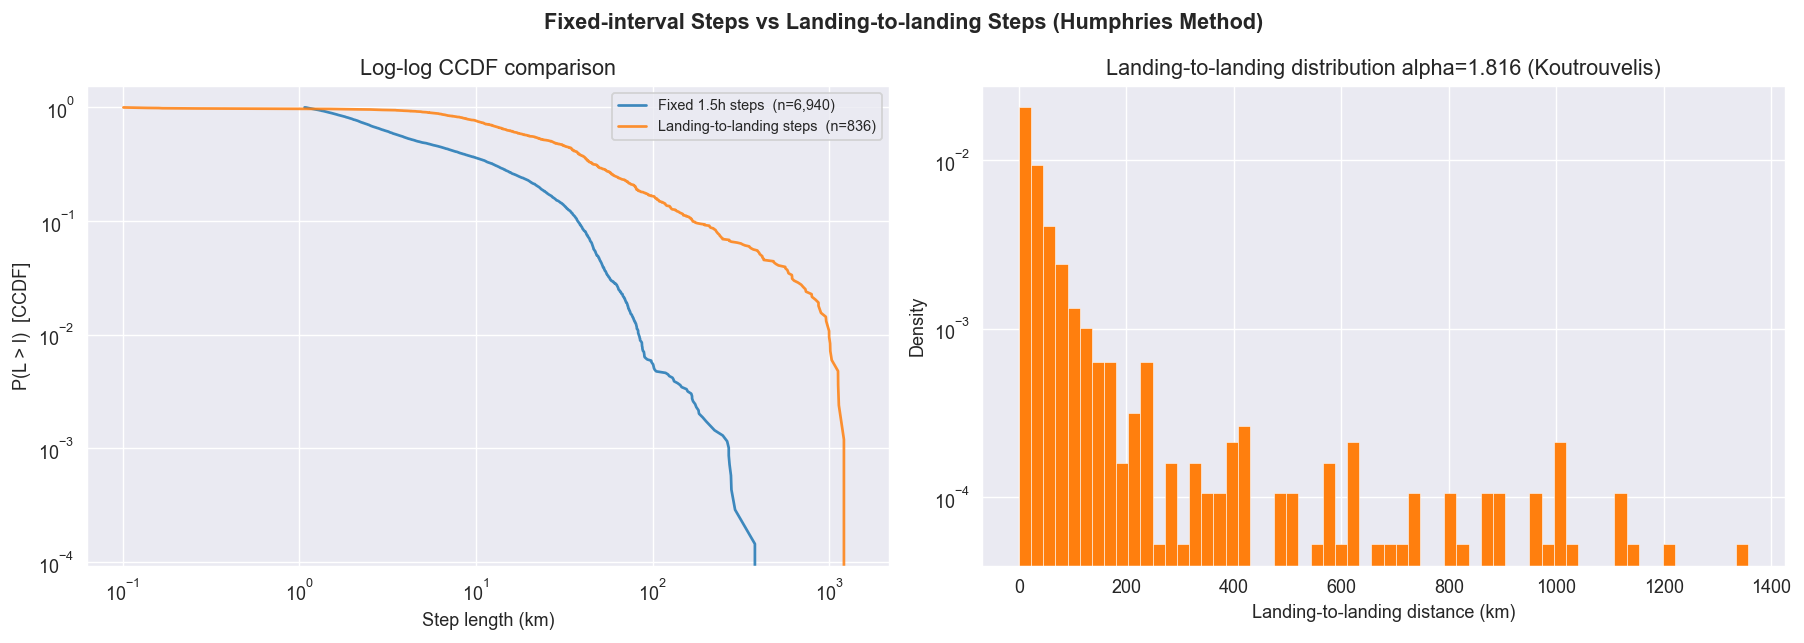

In [39]:
# Step 5 — Compare CCDF: fixed-interval steps vs landing-to-landing steps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fixed-interval Steps vs Landing-to-landing Steps (Humphries Method)",
             fontsize=12, fontweight="bold")

# CCDF comparison
ax = axes[0]
for label, sv, col in [
    ("Fixed 1.5h steps",         steps["step_m"].values, PALETTE[0]),
    ("Landing-to-landing steps", flight_vals,             PALETTE[1]),
]:
    sl_s = np.sort(sv[sv > 0])
    ccdf = 1 - np.arange(1, len(sl_s) + 1) / len(sl_s)
    ax.loglog(sl_s / 1000, ccdf, "-", color=col, linewidth=1.5,
              alpha=0.85, label=f"{label}  (n={len(sl_s):,})")
ax.set_xlabel("Step length (km)")
ax.set_ylabel("P(L > l)  [CCDF]")
ax.set_title("Log-log CCDF comparison")
ax.legend(fontsize=8)

# Step length histogram for landing-to-landing
ax = axes[1]
ax.hist(flight_vals / 1000, bins=60, color=PALETTE[1],
        edgecolor="white", linewidth=0.3, density=True)
ax.set_xlabel("Landing-to-landing distance (km)")
ax.set_ylabel("Density")
ax.set_title(f"Landing-to-landing distribution alpha={a_k:.3f} (Koutrouvelis)")
ax.set_yscale("log")

plt.tight_layout()
plt.savefig("fig_humphries_steps.png", bbox_inches="tight")
plt.show()

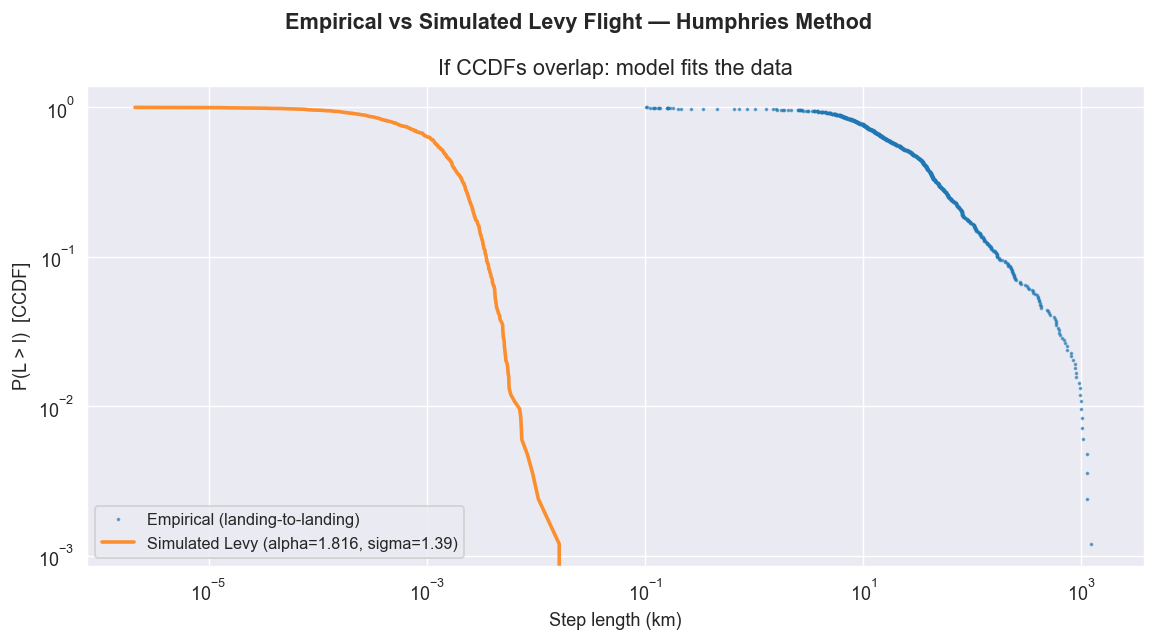

Fitted alpha = 1.8159
Expected for Levy foraging: alpha between 1.0 and 2.0
Result: Levy behaviour detected


In [ ]:
# Step 6 — Simulate Levy flight using fitted alpha from landing-to-landing steps
# and overlay simulated CCDF against empirical CCDF
np.random.seed(42)

n_sim        = len(flight_vals)
sim_steps    = np.abs(simulate_stable(a_k, beta=1, sigma=s_k, mu=0, n_steps=n_sim))

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Empirical vs Simulated Levy Flight — Humphries Method",
             fontsize=12, fontweight="bold")

# Empirical CCDF
sl_emp  = np.sort(flight_vals)
ccdf_emp = 1 - np.arange(1, len(sl_emp) + 1) / len(sl_emp)
ax.loglog(sl_emp / 1000, ccdf_emp, ".", markersize=2,
          alpha=0.6, color=PALETTE[0], label="Empirical (landing-to-landing)")

# Simulated CCDF
sl_sim   = np.sort(sim_steps[sim_steps > 0])
ccdf_sim = 1 - np.arange(1, len(sl_sim) + 1) / len(sl_sim)
ax.loglog(sl_sim / 1000, ccdf_sim, "-", linewidth=2,
          color=PALETTE[1], alpha=0.85,
          label=f"Simulated Levy (alpha={a_k:.3f}, sigma={s_k:.2f})")

ax.set_xlabel("Step length (km)")
ax.set_ylabel("P(L > l)  [CCDF]")
ax.set_title("If CCDFs overlap: model fits the data")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig_levy_fit_humphries.png", bbox_inches="tight")
plt.show()

print(f"Fitted alpha = {a_k:.4f}")
print(f"Expected for Levy foraging: alpha between 1.0 and 2.0")
print(f"Result: {'Levy behaviour detected' if a_k < 1.99 else 'No Levy behaviour — consistent with Brownian'}")